# IMF variations in `FASTAR`
To synthesize a new SSP model, the first step is always to specify the IMF parametrization while loading the synthesizer. 

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.ticker import ScalarFormatter

from fastar import IntegratedSSPSynthesizer
from fastar import imf

# Load the SSP synthesizer with a Salpeter-like IMF (single power law)
ssp = IntegratedSSPSynthesizer(imf_function=imf.single_power_law)

# Generate an SSP model (10 Gyr, solar metallicity for example)
spec = ssp.synthesize(age=10, met=0)

## Pre-defined functional forms
`FASTAR` comes with 6 pre-defined funtional forms. Let's have a look at them

In [ ]:
# To plot the different IMF, we first define a range of stellar masses
mass = np.linspace(0.1, 3, 1000)

# Then we can load all the different IMFs with their default parameters
bimodal = imf.bimodal(mass, params={})
salpeter = imf.single_power_law(mass, params={})
flexi = imf.flexi(mass, params={})
broken = imf.broken_power_law(mass, params={})
kroupa = imf.kroupa(mass, params={})
chabrier = imf.chabrier(mass, params={})

# Now we can see how they look
fig, ax = plt.subplots(figsize=(7, 5))

colors = {
    'Bimodal': '#edc407ff',
    'Salpeter': '#80c84cff',
    'Flexi': '#4d8e76ff',
    'Broken': '#973a8dff',
    'Kroupa': '#e2044fff',
    'Chabrier': '#4c4e8bff',
}

ax.plot(mass, salpeter, linewidth=2, label='Salpeter', color=colors['Salpeter'])
ax.plot(mass, bimodal, linewidth=2, label='Bimodal', color=colors['Bimodal'])
ax.plot(mass, kroupa, linewidth=2, label='Kroupa', color=colors['Kroupa'])
ax.plot(mass, chabrier, linewidth=2, label='Chabrier', color=colors['Chabrier'])
ax.plot(mass, flexi, linewidth=2, label='Tapered power-law', color=colors['Flexi'])
ax.plot(mass, broken, linewidth=2, label='Broken power-law', color=colors['Broken'])

leg = ax.legend(fontsize=12)
for line in leg.get_lines():
    line.set_linewidth(2)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$m \, [M_\odot]$')
ax.set_ylabel(r'$\chi(m)$')

ax.set_xticks([0.1, 0.3, 1, 3])
ax.get_xaxis().set_major_formatter(ScalarFormatter())

ax.tick_params(width=1.5, axis='both')
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

Now that we know how they look, let's generate SSP models with the same age and metallicity but different IMFs

In [ ]:
# Create six different synthesizers
ssp_single_power_law = IntegratedSSPSynthesizer(imf_function=imf.single_power_law)
ssp_bimodal = IntegratedSSPSynthesizer(imf_function=imf.bimodal)
ssp_flexi = IntegratedSSPSynthesizer(imf_function=imf.flexi)
ssp_broken_power_law = IntegratedSSPSynthesizer(imf_function=imf.broken_power_law)
ssp_kroupa = IntegratedSSPSynthesizer(imf_function=imf.kroupa)
ssp_chabrier = IntegratedSSPSynthesizer(imf_function=imf.chabrier)

# Synthesize the six SSPs
spec_single_power_law = ssp_single_power_law.synthesize(age=10, met=0)
spec_bimodal = ssp_bimodal.synthesize(age=10, met=0)
spec_broken_power_law = ssp_broken_power_law.synthesize(age=10, met=0)
spec_flexi = ssp_flexi.synthesize(age=10, met=0)
spec_kroupa = ssp_kroupa.synthesize(age=10, met=0)
spec_chabrier = ssp_chabrier.synthesize(age=10, met=0)

wave = ssp_chabrier.wave

# Finally plotting all the spectra
fig, ax = plt.subplots(figsize=(7, 5))

colors = {
    'Bimodal': '#edc407ff',
    'Salpeter': '#80c84cff',
    'Flexi': '#4d8e76ff',
    'Broken': '#973a8dff',
    'Kroupa': '#e2044fff',
    'Chabrier': '#4c4e8bff',
}

ax.plot(
    wave, spec_single_power_law, linewidth=1, label='Salpeter', color=colors['Salpeter']
)
ax.plot(wave, spec_bimodal, linewidth=1, label='Bimodal', color=colors['Bimodal'])
ax.plot(wave, spec_kroupa, linewidth=1, label='Kroupa', color=colors['Kroupa'])
ax.plot(wave, spec_chabrier, linewidth=1, label='Chabrier', color=colors['Chabrier'])
ax.plot(wave, spec_flexi, linewidth=1, label='Tapered power-law', color=colors['Flexi'])
ax.plot(
    wave,
    spec_broken_power_law,
    linewidth=1,
    label='Broken power-law',
    color=colors['Broken'],
)

leg = ax.legend(fontsize=12)
for line in leg.get_lines():
    line.set_linewidth(2)


ax.set_xlabel('Wavelength [Å]', fontsize=14)
ax.set_ylabel('F$_\lambda$ [erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$]', fontsize=14)

ax.tick_params(width=1.5, axis='both')
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

## Changing the IMF parameters
Each of the available functional forms has a set of parameters determining its actual shape. `FASTAR` has been coded with the idea of giving the user the freedom to generate SSP models for arbitrary combination of parameters. 

> ⚠️ **Important note**
>
> Changing the IMF mass limits (`m_min`, `m_max`) can significantly impact quantities such as mass-to-light ratios. However, it can also quickly lead to non-physical or unreliable model predictions.
>
> *With great power comes great responsibility.*

The free parameters of each IMF are described in the documentation and in the `FASTAR` papers. The synthesis flexibility can be illustrated, for example, with the tapered power-law IMF of de Marchi, Paresce & Portegies Zwart (2005). Changes in the IMF parameters are passed through a dictionary.

In [ ]:
# Let's use as reference the default values
spec_ref = ssp_flexi.synthesize(age=10, met=0)

# Change in the high-mass end slope (default alpha = 2.3)
spec_var1 = ssp_flexi.synthesize(age=10, met=0, imf_params={'alpha': 3})

# Sharpness of the exponential taper (default beta = 2.3)
spec_var2 = ssp_flexi.synthesize(age=10, met=0, imf_params={'beta': 1.5})

# Varying the characteristic mass (default m_peak = 0.5)
spec_var3 = ssp_flexi.synthesize(age=10, met=0, imf_params={'m_peak': 0.2})

# Plotting all the spectra
fig, ax = plt.subplots(figsize=(7, 5))

colors = {
    'Ref': '#4d8e76ff',
    'Var1': '#973a8dff',
    'Var2': '#e2044fff',
    'Var3': '#4c4e8bff',
}

ax.plot(wave, spec_ref, linewidth=1, label='Default', color=colors['Ref'])
ax.plot(wave, spec_var1, linewidth=1, label='High-mass slope', color=colors['Var1'])
ax.plot(wave, spec_var2, linewidth=1, label='Tapering', color=colors['Var2'])
ax.plot(wave, spec_var3, linewidth=1, label='Characteristic mass', color=colors['Var3'])

leg = ax.legend(fontsize=12)
for line in leg.get_lines():
    line.set_linewidth(2)


ax.set_xlabel('Wavelength [Å]', fontsize=14)
ax.set_ylabel('F$_\lambda$ [erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$]', fontsize=14)

ax.tick_params(width=1.5, axis='both')
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

For consistency, it is also possible to have a look at the changes in the shape of the IMF

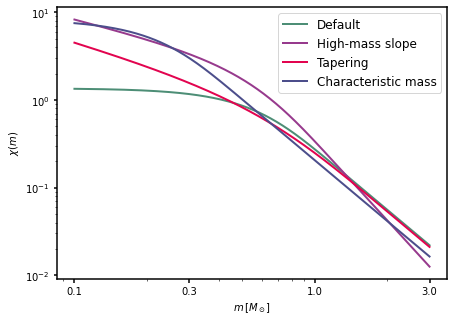

In [22]:
flexi_ref = imf.flexi(mass, params={})
flexi_var1 = imf.flexi(mass, params={'alpha': 3})
flexi_var2 = imf.flexi(mass, params={'beta': 1.5})
flexi_var3 = imf.flexi(mass, params={'m_peak': 0.2})

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(mass, flexi_ref, linewidth=2, label='Default', color=colors['Ref'])
ax.plot(mass, flexi_var1, linewidth=2, label='High-mass slope', color=colors['Var1'])
ax.plot(mass, flexi_var2, linewidth=2, label='Tapering', color=colors['Var2'])
ax.plot(
    mass, flexi_var3, linewidth=2, label='Characteristic mass', color=colors['Var3']
)

leg = ax.legend(fontsize=12)
for line in leg.get_lines():
    line.set_linewidth(2)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$m \, [M_\odot]$')
ax.set_ylabel(r'$\chi(m)$')

ax.set_xticks([0.1, 0.3, 1, 3])
ax.get_xaxis().set_major_formatter(ScalarFormatter())

ax.tick_params(width=1.5, axis='both')
for spine in ax.spines.values():
    spine.set_linewidth(1.5)